In [2]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from scipy.integrate import dblquad
from scipy.stats import multivariate_normal
#import numpyro
import matplotlib.pyplot as plt
from scipy.special import logsumexp

In [24]:
def pyro_model_(data, parameter_len, epsilon, prior_sigma):
    prior_parameter = pyro.sample("prior_parameter", dist.MultivariateNormal(torch.zeros(parameter_len), torch.eye(parameter_len)*prior_sigma))
    mean = torch.tensor([prior_parameter[0] - torch.max(prior_parameter), prior_parameter[1]]).float()
    with pyro.plate("data_plate"):
        pyro.sample("obs", dist.MultivariateNormal(mean, (epsilon**2)*torch.eye(len(data))), obs=data)    


def run_HMC(data, parameter_len, epsilon, prior_sigma, stepsize, num_samples, initial_params, warmup_steps):

    pyro.clear_param_store()
    pyro_model = lambda data: pyro_model_(data=data, parameter_len=parameter_len, epsilon=epsilon, prior_sigma=prior_sigma)
    pyro_kernel =  pyro.infer.mcmc.NUTS(model=pyro_model, step_size=stepsize)
    pyro_mcmc = pyro.infer.mcmc.MCMC(kernel=pyro_kernel, num_samples=num_samples, initial_params={'prior_parameter': initial_params}, warmup_steps=warmup_steps)
    pyro_mcmc.run(data)
    samples = pyro_mcmc.get_samples()["prior_parameter"]
                    
    return samples



In [21]:
def ABC_prob(epsilon, prior_sigma, data):
    def fn_(y, x, epsilon, prior_sigma):
        #y is theta2, x is theta1
        lh = multivariate_normal.pdf(data.numpy(), mean=np.array([x - np.maximum(x,y), y]), cov=epsilon**2)
        pr = multivariate_normal.pdf(np.array([x,y]), mean=np.array([0.,0.]), cov=prior_sigma**2)
        return lh*pr
    fn = lambda y, x: fn_(y, x, epsilon=epsilon, prior_sigma=prior_sigma)
    numerator = dblquad(fn, -np.inf, np.inf, lambda x:x, np.inf)[0]
    denominator = dblquad(fn, -np.inf, np.inf, -np.inf, np.inf)[0]
    return numerator / denominator

In [22]:
def GR(x):
    return numpyro.diagnostics.gelman_rubin(x)

def ABC_error(p_eps):
    return (1-p_eps)**2

def MCMC_error(p_eps, weights, particles):
    return (p_eps - np.sum([weights[i] for i in range(len(weights)) if particles[i][1] > particles[i][0]]))**2

def Overall_error(weights, particles):
    return (1 - np.sum([weights[i] for i in range(len(weights)) if particles[i][1] > particles[i][0]]))**2


In [55]:
#main parameter
data = torch.tensor([-1.,-1.])
parameter_len = 2
prior_sigma = 1.


# ####amendable parameter

initial_eps = 10.
num_particles = 200
eps_range = [0.1, 0.3, 0.5, 0.7, 0.9]
#eps_range = [0.1,0.3,0.5,0.7,0.9]

initial_warmup_steps = 1000
resample_rate = 100
initial_num_samples = num_particles*resample_rate
initial_params = torch.tensor([-2.,-1.])
stepsize = 0.1

warmup_steps = 20
num_samples = 100

#testing parameters
# num_particles = 2
# eps_range = [0.1,0.3]
# initial_warmup_steps = 1
# resample_rate = 1
# initial_num_samples = num_particles*resample_rate
# initial_params = torch.tensor([0.,0.])
# stepsize = 0.1

# warmup_steps = 2
# num_samples = 5



p0_samples = run_HMC(data=data, 
        parameter_len=parameter_len, 
        epsilon=initial_eps, 
        prior_sigma=prior_sigma, 
        stepsize=stepsize, 
        num_samples=initial_num_samples, 
        initial_params=initial_params, 
        warmup_steps=initial_warmup_steps).numpy()[::resample_rate]



#SMC
all_particles_full = []
all_particles = []
all_weights = []
#all_gr = []
all_abcerror = []
all_mcmcerror = []
all_overallerror = []

for eps in eps_range:
    logweights = np.zeros(num_particles)
    particles = np.zeros([num_particles,parameter_len])
    particles_full = np.zeros([num_particles, num_samples, parameter_len])
    for n in range(num_particles):
        print("Working on eps {}, particle, {}...".format(eps, n))
        #smc
        sample = p0_samples[n]
        wn = -1/(2*eps**2)*((data.numpy()[0]-(sample[0]-np.max(sample)))**2+(data.numpy()[1]-sample[1])**2)
        logweights[n] = wn
        
        #MCMC
        pn = run_HMC(data=data, 
                parameter_len=parameter_len, 
                epsilon=eps, 
                prior_sigma=prior_sigma, 
                stepsize=stepsize, 
                num_samples=num_samples, 
                initial_params=torch.tensor(p0_samples[n]), 
                warmup_steps=warmup_steps).numpy()
        particles[n] = pn[-1]
        particles_full[n] = pn
    
    weights = np.exp(logweights - logsumexp(logweights))
    
    all_particles_full.append(particles_full)
    all_particles.append(particles)
    all_weights.append(weights)
    
    
    #Metrics
    #gr = np.array([GR(np.array(particles_full)[:,:,0]),GR(np.array(particles_full)[:,:,1])])
    p_eps = ABC_prob(eps, prior_sigma, data)
    abcerror = ABC_error(p_eps)
    mcmcerror = MCMC_error(p_eps, weights, particles)
    overallerror = Overall_error(weights, particles)
    
    #all_gr.append(gr)
    all_abcerror.append(abcerror)
    all_mcmcerror.append(mcmcerror)
    all_overallerror.append(overallerror)
    
    np.savez("../abcerrorresults/eps{}.npz".format(str(eps).replace(".","-")),
        particles_full=particles_full, 
             particles=particles, 
             weights=weights,
            #gr=gr,
            abcerror=abcerror,
            mcmcerror=mcmcerror,
            overallerror=overallerror)
    

Sample: 100%|████████████████████████████████████| 21000/21000 [01:54, 183.16it/s, step size=8.82e-01, acc. prob=0.914]


Working on eps 0.1, particle, 0...


Sample: 100%|█████████████████████████████████████████| 120/120 [00:40,  2.95it/s, step size=1.63e-01, acc. prob=0.187]


Working on eps 0.1, particle, 1...


Sample: 100%|█████████████████████████████████████████| 120/120 [01:13,  1.64it/s, step size=2.58e-02, acc. prob=0.172]


...

Sample: 100%|█████████████████████████████████████████| 120/120 [00:04, 25.44it/s, step size=1.49e+00, acc. prob=0.610]


Working on eps 0.9, particle, 198...


Sample: 100%|█████████████████████████████████████████| 120/120 [00:12,  9.67it/s, step size=1.08e+00, acc. prob=0.691]


Working on eps 0.9, particle, 199...


Sample: 100%|█████████████████████████████████████████| 120/120 [00:03, 33.69it/s, step size=1.76e-01, acc. prob=0.728]


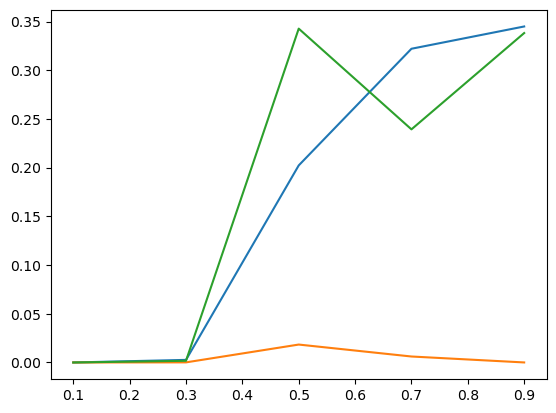

In [56]:
plt.plot(eps_range, all_abcerror)
plt.plot(eps_range, all_mcmcerror)
plt.plot(eps_range, all_overallerror)

In [68]:
file001 = np.load("../abcerrorresults/eps{}.npz".format("0-01"))
file001["particles"]

array([[-1.98775589, -0.99875867],
       [-2.00326133, -1.00819731],
       [-2.00980616, -0.98820609],
       [-1.99643159, -0.99991995],
       [-2.00288677, -0.99475253],
       [-1.99919689, -1.00562978],
       [-1.98818135, -0.99263114],
       [-1.98754227, -0.98780531],
       [-1.99953413, -1.00162828],
       [-2.00795794, -1.00613105],
       [-2.02039695, -1.0089606 ],
       [-2.00111055, -0.99636668],
       [-1.42899597, -0.64261246],
       [ 0.17575385, -0.99405962],
       [-1.99773121, -1.00083351],
       [-1.98785031, -0.98395008],
       [-2.00161099, -1.00097489],
       [-1.98507082, -0.99694216],
       [-1.98945236, -0.99584186],
       [-1.96297967, -0.98342669],
       [-2.00226378, -0.99503857],
       [-1.82360673, -0.88286537],
       [-2.01749945, -1.00840604],
       [-1.97768259, -0.98129582],
       [-2.00818849, -1.0074389 ],
       [-1.98439181, -0.99240255],
       [-2.02003241, -1.00140882],
       [ 1.14006758, -0.99549085],
       [-2.01653314,

In [41]:
all_particles

[array([[-1.84093082, -0.91824836],
        [-2.13671398, -1.21110201],
        [-1.96859145, -0.98211354],
        [-1.77674723, -0.89536166],
        [-1.80777061, -0.76734138],
        [-2.05834723, -1.0585283 ],
        [-1.88713276, -0.77028644],
        [-1.89415359, -0.81031948],
        [-2.08666754, -1.09898448],
        [-1.97702217, -0.85553253],
        [-2.05210471, -0.94825786],
        [-1.7861408 , -0.98039711],
        [-1.98952734, -1.06049943],
        [-1.92537355, -0.91200262],
        [-2.11891174, -0.95797831],
        [-2.04184556, -1.10085464],
        [-1.80685997, -0.87220925],
        [-1.81527662, -0.92501658],
        [-1.90995228, -0.91774172],
        [-1.83050907, -0.88775778],
        [-1.93175197, -0.90116102],
        [-1.83347011, -0.82260597],
        [-2.03685951, -0.95399553],
        [-2.09553719, -0.9379254 ],
        [-2.01205778, -0.95328236],
        [-2.01522231, -0.92719537],
        [-2.08985949, -1.03498363],
        [-1.8308928 , -0.853

In [35]:
all_abcerror

[5.844511461343226e-17,
 0.002658089242543607,
 0.20228033668850504,
 0.322041168098648,
 0.34490573223364823]

In [34]:
all_mcmcerror = [MCMC_error( ABC_prob(eps, prior_sigma, data), ) for i in all_abcerror]

In [ ]:
all_ab